In [1]:
"""
1. Injection of global noise via phase shifts and
by frequency offsets.

2. Injection of global and local noise via single
addressing beams causing stark shifts.

"""

import graph_style as gs
import fig_helper as fh
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

gs.set_graph_style(246/510)

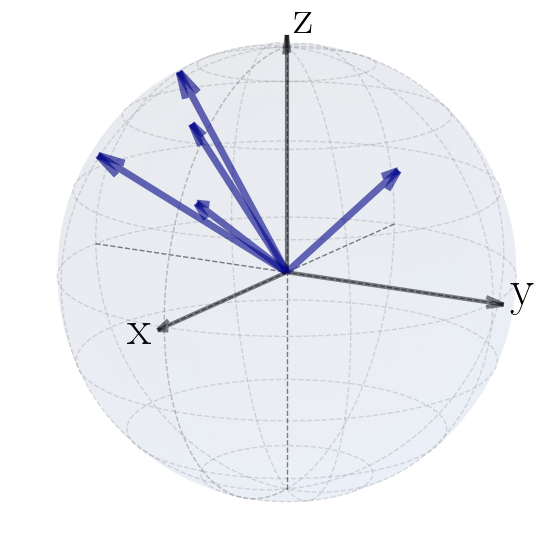

In [14]:
# Bloch sphere with labeled X, Y, Z axes and one state vector |psi>
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

gs.set_graph_style(1)

def unit(v):
    v = np.asarray(v, dtype=float)
    return v / np.linalg.norm(v)

def slerp(v1, v2, t):
    """Great-circle interpolation between unit vectors."""
    v1 = unit(v1)
    v2 = unit(v2)
    dot = np.clip(np.dot(v1, v2), -1.0, 1.0)
    omega = np.arccos(dot)

    if np.isclose(omega, 0):
        return np.outer(np.ones_like(t), v1)

    so = np.sin(omega)
    return (np.sin((1 - t) * omega)[:, None] * v1 +
            np.sin(t * omega)[:, None] * v2) / so


def plot_spherical_triangle(ax, v1, v2, n_arc=100, n_radial=40,
                            color='orange', alpha=0.6, length=1.0):
    """
    Plot the 2D surface bounded by:
    - radial vector v1
    - radial vector v2
    - geodesic arc between them
    """

    # geodesic arc
    t = np.linspace(0, 1, n_arc)
    arc = slerp(v1, v2, t)      # shape (n_arc, 3)

    # radial scaling from origin
    r = np.linspace(0, length, n_radial)

    X = np.zeros((n_radial, n_arc))
    Y = np.zeros_like(X)
    Z = np.zeros_like(X)

    for i in range(n_radial):
        scaled = r[i] * arc
        X[i, :] = scaled[:, 0]
        Y[i, :] = scaled[:, 1]
        Z[i, :] = scaled[:, 2]

    ax.plot_surface(X, Y, Z, linewidth=0, antialiased=True,
                    alpha=alpha, color=color)


def rod_form(theta, n):
        """Rodrigues' rotation formula to get rotation matrix from angle and axis"""
        return (np.cos(theta) * np.identity(3)
            + (1 - np.cos(theta)) * np.outer(n, n)
            + np.sin(theta)
            * np.array([[0, -n[2], n[1]], [n[2], 0, -n[0]], [-n[1], n[0], 0]]))



# Create sphere mesh
u = np.linspace(0, 2*np.pi, 120)
v = np.linspace(0, np.pi, 120)
U, V = np.meshgrid(u, v)

def sphere_to_cart(u, v):
    x = np.cos(u) * np.sin(v)
    y = np.sin(u) * np.sin(v)
    z = np.cos(v)
    return x, y, z

X = np.cos(U) * np.sin(V)
Y = np.sin(U) * np.sin(V)
Z = np.cos(V)

# Plot
fig_width =7
fig_height = fig_width
lin_width = 5
fig = plt.figure(figsize=(fig_width, fig_height))
ax = fig.add_subplot(111, projection='3d')

# Sphere surface
ax.plot_surface(X, Y, Z, alpha=0.05)

band_no = 9
v_bands = np.linspace(0, np.pi, band_no)
for v in v_bands:
    us = np.linspace(0, 2*np.pi, 100)
    x,y,z = sphere_to_cart(us, v*np.ones_like(us))
    ax.plot(x, y, z, color='gray', alpha=0.25)
h_bands = np.linspace(0, 2*np.pi, band_no)
for u in h_bands:
    vs = np.linspace(0, np.pi, 100)
    x,y,z = sphere_to_cart(u*np.ones_like(vs), vs)
    ax.plot(x, y, z, color='gray', alpha=0.25)

# Axes
L = 1
alpha = 0.5
ax.plot([-L, L], [0, 0], [0, 0], color='black', alpha=alpha)
ax.plot([0, 0], [-L, L], [0, 0], color='black', alpha=alpha)
ax.plot([0, 0], [0, 0], [-L, L], color='black', alpha=alpha)

# Axis arrows
ax.quiver(0, 0, 0, 1.05, 0, 0, arrow_length_ratio=0.08, color='black', alpha=alpha, linewidth=3)
ax.quiver(0, 0, 0, 0, 1.05, 0, arrow_length_ratio=0.08, color='black', alpha=alpha, linewidth=3)
ax.quiver(0, 0, 0, 0, 0, 1.05, arrow_length_ratio=0.08, color='black', alpha=alpha, linewidth=3)

# Axis labels
f_size = 36
let_ofs = 1.08
ax.text(let_ofs+0.2, 0, 0, 'x', fontsize=f_size)
ax.text(0, let_ofs, 0, 'y', fontsize=f_size)
ax.text(0, 0.03, let_ofs-0.02, 'z', fontsize=f_size)

# State vector Qj
# rotate arrow head
num_arrows = 5
t_d = np.pi/3
for i in range(num_arrows):
    nx = np.random.uniform(-1, 1)
    ny = np.random.uniform(-1, 1)
    nz = np.random.uniform(-1, 1)
    n_d = [nx, ny, nz]
    n_d = n_d / np.linalg.norm(n_d)
    Rd = rod_form(t_d, np.array(n_d))
    Q1 = Rd @ np.array([0, 0, 1])
    ax.quiver(0, 0, 0, Q1[0], Q1[1], Q1[2], color="darkblue", linewidth=lin_width, arrow_length_ratio=0.12, alpha=0.6)
# ket_label = r"$|\psi_j\rangle$"
# ax.text(Q1[0]*1.15, Q1[1]*1.15, Q1[2]*1.15, ket_label, color="black", fontsize=f_size)


# Formatting
lim_val = 0.7
ax.set_xlim([-1*lim_val, lim_val])
ax.set_ylim([-1*lim_val, lim_val])
ax.set_zlim([-1*lim_val, lim_val])

x, y, z = sphere_to_cart(np.pi/2, np.pi/2)
try:
    ax.set_box_aspect([1, 1, 1])
except:
    pass

ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])

# hide axis
ax.set_axis_off()
ax.view_init(elev=15, azim=30, roll=0)

# f_path = "..\\pdf_figure\\f1_corr.pdf"
f_path = "..\\pdf_figure\\f1_depol2.pdf"
# transparent background
fig.savefig(f_path, bbox_inches='tight', transparent=True)
